# 00 — Data Acquisition: Sentinel-2 L2A for One Field
Downloads six weekly **Sentinel-2 Level-2A** (surface reflectance, atmospherically corrected)
scenes for a single agricultural field, then inspects, resamples, and stacks the bands into
an aligned image cube — the raw input the rest of the `crop_ai` pipeline expects.

```
Field
│
├── June 1
├── June 8
├── June 15
├── June 22
├── June 29
└── July 6
```

**Source:** [Microsoft Planetary Computer](https://planetarycomputer.microsoft.com/) STAC API,
`sentinel-2-l2a` collection. No account or API key needed — assets are signed with a short-lived
SAS token per request. (Alternative sources: Copernicus Data Space Ecosystem, AWS `sentinel-cogs`,
Google Earth Engine — same band names, different auth.)

**Bands:** B02, B03, B04, B05, B06, B07, B08, B8A, B11, B12 (+ SCL for cloud masking)

> ⚠️ **Network note:** this notebook needs outbound internet access to
> `planetarycomputer.microsoft.com`. If you're running somewhere with a locked-down network
> (e.g. a sandboxed container), set `USE_SYNTHETIC = True` below to generate a georeferenced
> stand-in dataset with the *same* shapes/resolutions/missing-data patterns, so you can still
> run and verify every inspection/resampling/stacking step in this notebook.

In [1]:
import os
import sys
sys.path.append(os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import from_origin
from rasterio.warp import reproject, Resampling
from rasterio.plot import show

from preprocessing import SENTINEL2_BANDS, SENTINEL2_NATIVE_RES_M

# --- toggle this ---
USE_SYNTHETIC = True   # set False once you have real internet access to Planetary Computer
# --------------------

FIELD_ID = "field_001"
# Real bounding box for a rice field in the Cauvery delta, Thanjavur, Tamil Nadu, India
# (lon_min, lat_min, lon_max, lat_max) — roughly 2.5 km x 2.5 km
FIELD_BBOX = [79.110, 10.760, 79.135, 10.785]

WEEK_STARTS = pd.date_range("2024-06-01", "2024-07-06", freq="7D")
BANDS = SENTINEL2_BANDS + ["SCL"]  # SCL = Scene Classification Layer, used for cloud masking

RAW_NATIVE_DIR = f"../data/raw/sentinel2_native/{FIELD_ID}"   # per-band, native resolution
ALIGNED_DIR = f"../data/raw/sentinel2/{FIELD_ID}"             # final aligned 10 m cube per date
os.makedirs(RAW_NATIVE_DIR, exist_ok=True)
os.makedirs(ALIGNED_DIR, exist_ok=True)

print("dates:", [d.date().isoformat() for d in WEEK_STARTS])
print("bands:", BANDS)


dates: ['2024-06-01', '2024-06-08', '2024-06-15', '2024-06-22', '2024-06-29', '2024-07-06']
bands: ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12', 'SCL']


## Step 1 — Search & download (real path)
Finds the least-cloudy Sentinel-2 L2A scene within ±2 days of each target date and downloads/clips each requested band to the field's bounding box. Skip this cell if `USE_SYNTHETIC = True`.

In [2]:
if not USE_SYNTHETIC:
    import pystac_client
    import planetary_computer
    import rioxarray

    catalog = pystac_client.Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        modifier=planetary_computer.sign_inplace,
    )

    def find_best_scene(week_start, bbox, max_cloud=40):
        window = (week_start - pd.Timedelta(days=2), week_start + pd.Timedelta(days=2))
        search = catalog.search(
            collections=["sentinel-2-l2a"],
            bbox=bbox,
            datetime=f"{window[0].date()}/{window[1].date()}",
            query={"eo:cloud_cover": {"lt": max_cloud}},
        )
        items = list(search.items())
        if not items:
            return None
        items.sort(key=lambda it: it.properties["eo:cloud_cover"])
        return items[0]

    selected_items = {}
    for week_start in WEEK_STARTS:
        item = find_best_scene(week_start, FIELD_BBOX)
        date_str = week_start.date().isoformat()
        if item is None:
            print(f"{date_str} -> no cloud-free scene found in window, skipping")
            continue
        selected_items[date_str] = item
        print(f"{date_str} -> {item.id}  cloud_cover={item.properties['eo:cloud_cover']:.1f}%")

    for date_str, item in selected_items.items():
        out_dir = os.path.join(RAW_NATIVE_DIR, date_str)
        os.makedirs(out_dir, exist_ok=True)
        for band in BANDS:
            out_path = os.path.join(out_dir, f"{band}.tif")
            if os.path.exists(out_path):
                continue
            da = rioxarray.open_rasterio(item.assets[band].href)
            da_clip = da.rio.clip_box(*FIELD_BBOX, crs="EPSG:4326")
            da_clip.rio.to_raster(out_path)
        print(f"downloaded bands for {date_str}")
else:
    print("USE_SYNTHETIC=True — skipping real download, see synthetic generator below")


USE_SYNTHETIC=True — skipping real download, see synthetic generator below


## Step 1 (alt) — Synthetic stand-in generator
Writes real, georeferenced GeoTIFFs at each band's correct **native resolution** (10 m for B02/B03/B04/B08, 20 m for the rest), with a smooth NDVI-like crop growth curve across the six weeks and a deliberately stressed patch in one corner — so the rest of this notebook (and the risk-map model in `05_cnn_lstm.ipynb`) has something meaningful to look at. Runs only if `USE_SYNTHETIC = True`.

In [3]:
from scipy.ndimage import gaussian_filter

FIELD_WIDTH_M = 2560   # -> 256 px at 10 m / 128 px at 20 m
FIELD_HEIGHT_M = 2560
ORIGIN = (753000, 1192000)   # arbitrary UTM-like origin, zone 44N covers Tamil Nadu
CRS = "EPSG:32644"


def smooth_field(height, width, seed, low, high):
    rng = np.random.default_rng(seed)
    noise = rng.normal(size=(height, width))
    smooth = gaussian_filter(noise, sigma=max(height, width) / 12)
    smooth = (smooth - smooth.min()) / (smooth.max() - smooth.min() + 1e-8)
    return low + smooth * (high - low)


def add_stress_patch(arr, corner_frac=0.28, reduction=0.4):
    h, w = arr.shape
    ph, pw = int(h * corner_frac), int(w * corner_frac)
    patch = arr[:ph, :pw]
    arr[:ph, :pw] = patch * (1 - reduction)
    return arr


def write_band(path, arr, resolution_m, nodata=0, dtype="uint16"):
    h, w = arr.shape
    transform = from_origin(ORIGIN[0], ORIGIN[1], resolution_m, resolution_m)
    profile = dict(driver="GTiff", dtype=dtype, width=w, height=h, count=1,
                   crs=CRS, transform=transform, nodata=nodata)
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(arr.astype(dtype), 1)


if USE_SYNTHETIC:
    growth_curve = np.array([0.30, 0.45, 0.62, 0.75, 0.80, 0.70])  # NDVI-like phenology, week 6 dips (stress)

    for week_i, week_start in enumerate(WEEK_STARTS):
        date_str = week_start.date().isoformat()
        out_dir = os.path.join(RAW_NATIVE_DIR, date_str)
        os.makedirs(out_dir, exist_ok=True)
        veg = growth_curve[week_i]

        for band in BANDS:
            res_m = SENTINEL2_NATIVE_RES_M.get(band, 20)  # SCL ships at 20 m too
            h = w = FIELD_HEIGHT_M // res_m

            if band == "B08" or band == "B8A":       # NIR — high & rising with vegetation
                base = smooth_field(h, w, seed=week_i * 10 + 1, low=1500, high=1500 + veg * 3500)
            elif band == "B04":                        # Red — drops as canopy closes
                base = smooth_field(h, w, seed=week_i * 10 + 2, low=300 + (1 - veg) * 1200, high=800 + (1 - veg) * 1500)
            elif band in ("B02", "B03"):                # Blue/Green — fairly stable
                base = smooth_field(h, w, seed=week_i * 10 + 3, low=400, high=1200)
            elif band in ("B05", "B06", "B07"):         # Red-edge — tracks NIR loosely
                base = smooth_field(h, w, seed=week_i * 10 + 4, low=800, high=800 + veg * 2500)
            elif band in ("B11", "B12"):                # SWIR — moisture-sensitive, inverse-ish to NIR
                base = smooth_field(h, w, seed=week_i * 10 + 5, low=600 + (1 - veg) * 1500, high=1200 + (1 - veg) * 2000)
            elif band == "SCL":
                base = np.full((h, w), 4, dtype=np.float32)  # 4 = vegetation class, mostly clear
            else:
                base = smooth_field(h, w, seed=week_i * 10 + 9, low=500, high=1500)

            base = add_stress_patch(base, reduction=0.35 if band in ("B08", "B8A", "B05", "B06", "B07") else -0.15)
            # small fraction of true nodata pixels along one edge, to exercise the missing-value check
            base = base.copy()
            base[:3, :] = 0

            write_band(os.path.join(out_dir, f"{band}.tif"), np.clip(base, 0, 10000),
                       resolution_m=res_m, dtype="uint16" if band != "SCL" else "uint8")

        print(f"synthetic bands written for {date_str}")

    selected_items = {d.date().isoformat(): None for d in WEEK_STARTS}  # keep downstream code uniform


synthetic bands written for 2024-06-01
synthetic bands written for 2024-06-08
synthetic bands written for 2024-06-15
synthetic bands written for 2024-06-22


synthetic bands written for 2024-06-29
synthetic bands written for 2024-07-06


## Step 2 — Inspect the raw data
Before any ML: load each band and check shape, dtype, min/max/mean, and missing-value count.

In [4]:
def inspect_band(path):
    with rasterio.open(path) as src:
        arr = src.read(1)
        nodata = src.nodata
        missing = int((arr == nodata).sum()) if nodata is not None else 0
        return {
            "shape": arr.shape,
            "resolution_m": round(src.res[0], 1),
            "dtype": str(arr.dtype),
            "min": float(arr.min()),
            "max": float(arr.max()),
            "mean": float(arr.mean()),
            "missing_px": missing,
            "missing_pct": round(100 * missing / arr.size, 3),
        }


first_date = sorted(selected_items.keys())[0]
sample_dir = os.path.join(RAW_NATIVE_DIR, first_date)

rows = []
for band in BANDS:
    stats = inspect_band(os.path.join(sample_dir, f"{band}.tif"))
    stats["band"] = band
    rows.append(stats)

inspection_df = pd.DataFrame(rows).set_index("band")[
    ["shape", "resolution_m", "dtype", "min", "max", "mean", "missing_px", "missing_pct"]
]
inspection_df


,shape,resolution_m,dtype,min,max,mean,missing_px,missing_pct
band,,,,,,,,
B02,"(256, 256)",10.0,uint16,0.0,1199.0,812.420929,768,1.172
B03,"(256, 256)",10.0,uint16,0.0,1199.0,812.420929,768,1.172
B04,"(256, 256)",10.0,uint16,0.0,2025.0,1479.311279,768,1.172
B05,"(128, 128)",20.0,uint16,0.0,1549.0,1186.568665,384,2.344
B06,"(128, 128)",20.0,uint16,0.0,1549.0,1186.568665,384,2.344
B07,"(128, 128)",20.0,uint16,0.0,1549.0,1186.568665,384,2.344
B08,"(256, 256)",10.0,uint16,0.0,2549.0,2075.213593,768,1.172
B8A,"(128, 128)",20.0,uint16,0.0,2549.0,1993.925415,384,2.344
B11,"(128, 128)",20.0,uint16,0.0,2989.0,2167.108521,384,2.344


Note the two resolution groups: **10 m** (B02, B03, B04, B08) with larger pixel dimensions, and **20 m** (B05, B06, B07, B8A, B11, B12, SCL) with half the width/height for the same ground area — this is exactly the mismatch Step 4 resolves.

## Step 3 — Display B04, B08, and an RGB composite
Sanity check before doing anything else.

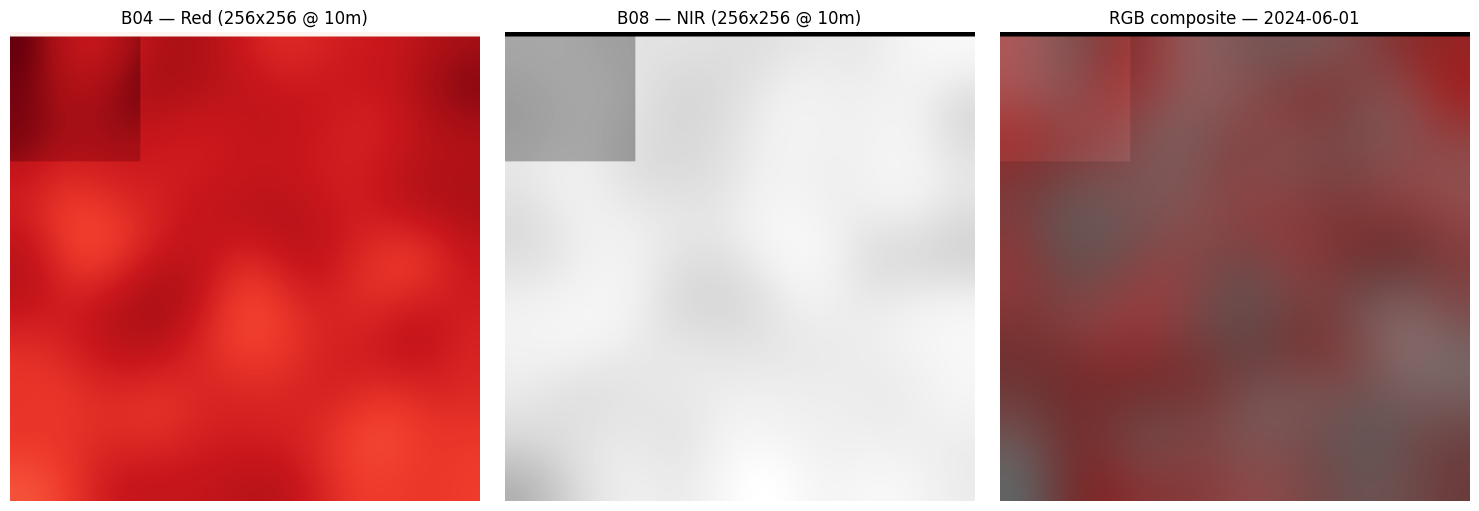

In [5]:
with rasterio.open(os.path.join(sample_dir, "B04.tif")) as src:
    b04 = src.read(1).astype(float)
with rasterio.open(os.path.join(sample_dir, "B08.tif")) as src:
    b08 = src.read(1).astype(float)
with rasterio.open(os.path.join(sample_dir, "B03.tif")) as src:
    b03 = src.read(1).astype(float)
with rasterio.open(os.path.join(sample_dir, "B02.tif")) as src:
    b02 = src.read(1).astype(float)

rgb = np.stack([b04, b03, b02], axis=-1)
rgb = np.clip(rgb / 3000, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(b04, cmap="Reds"); axes[0].set_title(f"B04 — Red ({b04.shape[0]}x{b04.shape[1]} @ 10m)")
axes[1].imshow(b08, cmap="Greys_r"); axes[1].set_title(f"B08 — NIR ({b08.shape[0]}x{b08.shape[1]} @ 10m)")
axes[2].imshow(rgb); axes[2].set_title(f"RGB composite — {first_date}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## Step 4 — Resample every band to a common 10 m grid
B02/B03/B04/B08 are already native 10 m — use one of them as the reference grid. The 20 m bands (B05, B06, B07, B8A, B11, B12) get reprojected onto that exact grid with bilinear resampling (continuous reflectance values — nearest-neighbor would be the right choice only for a categorical layer like SCL).

In [6]:
def resample_to_reference(src_path, ref_path, out_path, resampling=Resampling.bilinear):
    with rasterio.open(ref_path) as ref:
        ref_transform, ref_crs = ref.transform, ref.crs
        ref_width, ref_height = ref.width, ref.height

    with rasterio.open(src_path) as src:
        profile = src.profile.copy()
        profile.update(crs=ref_crs, transform=ref_transform, width=ref_width, height=ref_height)
        with rasterio.open(out_path, "w", **profile) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform, src_crs=src.crs,
                dst_transform=ref_transform, dst_crs=ref_crs,
                resampling=resampling,
            )


REFERENCE_BAND = "B04"  # any native 10 m band works as the target grid


## Step 5 — Stack into an aligned image cube per date
Resamples all 10 bands for every date onto the B04 grid and writes a single multi-band GeoTIFF per date to `data/raw/sentinel2/<field_id>/<date>.tif` — the exact layout `src/preprocessing.py` and the notebooks from Task 1 expect.

In [7]:
for date_str in sorted(selected_items.keys()):
    native_dir = os.path.join(RAW_NATIVE_DIR, date_str)
    ref_path = os.path.join(native_dir, f"{REFERENCE_BAND}.tif")

    resampled_paths = []
    for band in SENTINEL2_BANDS:
        src_path = os.path.join(native_dir, f"{band}.tif")
        out_path = os.path.join(native_dir, f"{band}_10m.tif")
        resampling = Resampling.bilinear
        resample_to_reference(src_path, ref_path, out_path, resampling=resampling)
        resampled_paths.append(out_path)

    with rasterio.open(resampled_paths[0]) as ref:
        profile = ref.profile.copy()
    profile.update(count=len(SENTINEL2_BANDS))

    out_path = os.path.join(ALIGNED_DIR, f"{date_str}.tif")
    with rasterio.open(out_path, "w", **profile) as dst:
        for i, p in enumerate(resampled_paths, start=1):
            with rasterio.open(p) as src:
                dst.write(src.read(1), i)
            dst.set_band_description(i, SENTINEL2_BANDS[i - 1])

    print(f"aligned cube saved: {out_path}  bands={SENTINEL2_BANDS}")


aligned cube saved: ../data/raw/sentinel2/field_001/2024-06-01.tif  bands=['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12']
aligned cube saved: ../data/raw/sentinel2/field_001/2024-06-08.tif  bands=['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12']
aligned cube saved: ../data/raw/sentinel2/field_001/2024-06-15.tif  bands=['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12']


aligned cube saved: ../data/raw/sentinel2/field_001/2024-06-22.tif  bands=['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12']
aligned cube saved: ../data/raw/sentinel2/field_001/2024-06-29.tif  bands=['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12']
aligned cube saved: ../data/raw/sentinel2/field_001/2024-07-06.tif  bands=['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12']


## Verify the aligned cube
All 10 bands should now report the same shape and 10 m resolution.

In [8]:
check_date = sorted(selected_items.keys())[0]
with rasterio.open(os.path.join(ALIGNED_DIR, f"{check_date}.tif")) as src:
    print("bands:", src.count)
    print("shape (H, W):", (src.height, src.width))
    print("resolution:", src.res)
    print("band descriptions:", src.descriptions)
    cube = src.read().astype(np.float32)

print("\ncube shape (C, H, W):", cube.shape)
for i, name in enumerate(SENTINEL2_BANDS):
    band = cube[i]
    print(f"  {name:4s}  min={band.min():7.1f}  max={band.max():7.1f}  mean={band.mean():7.1f}")


bands: 10
shape (H, W): (256, 256)
resolution: (10.0, 10.0)
band descriptions: ('B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12')

cube shape (C, H, W): (10, 256, 256)
  B02   min=    0.0  max= 1199.0  mean=  812.4
  B03   min=    0.0  max= 1199.0  mean=  812.4
  B04   min=    0.0  max= 2025.0  mean= 1479.3
  B05   min=    0.0  max= 1549.0  mean= 1186.6
  B06   min=    0.0  max= 1549.0  mean= 1186.6
  B07   min=    0.0  max= 1549.0  mean= 1186.6
  B08   min=    0.0  max= 2549.0  mean= 2075.2
  B8A   min=    0.0  max= 2549.0  mean= 1994.0
  B11   min=    0.0  max= 2989.0  mean= 2167.2
  B12   min=    0.0  max= 2989.0  mean= 2167.2


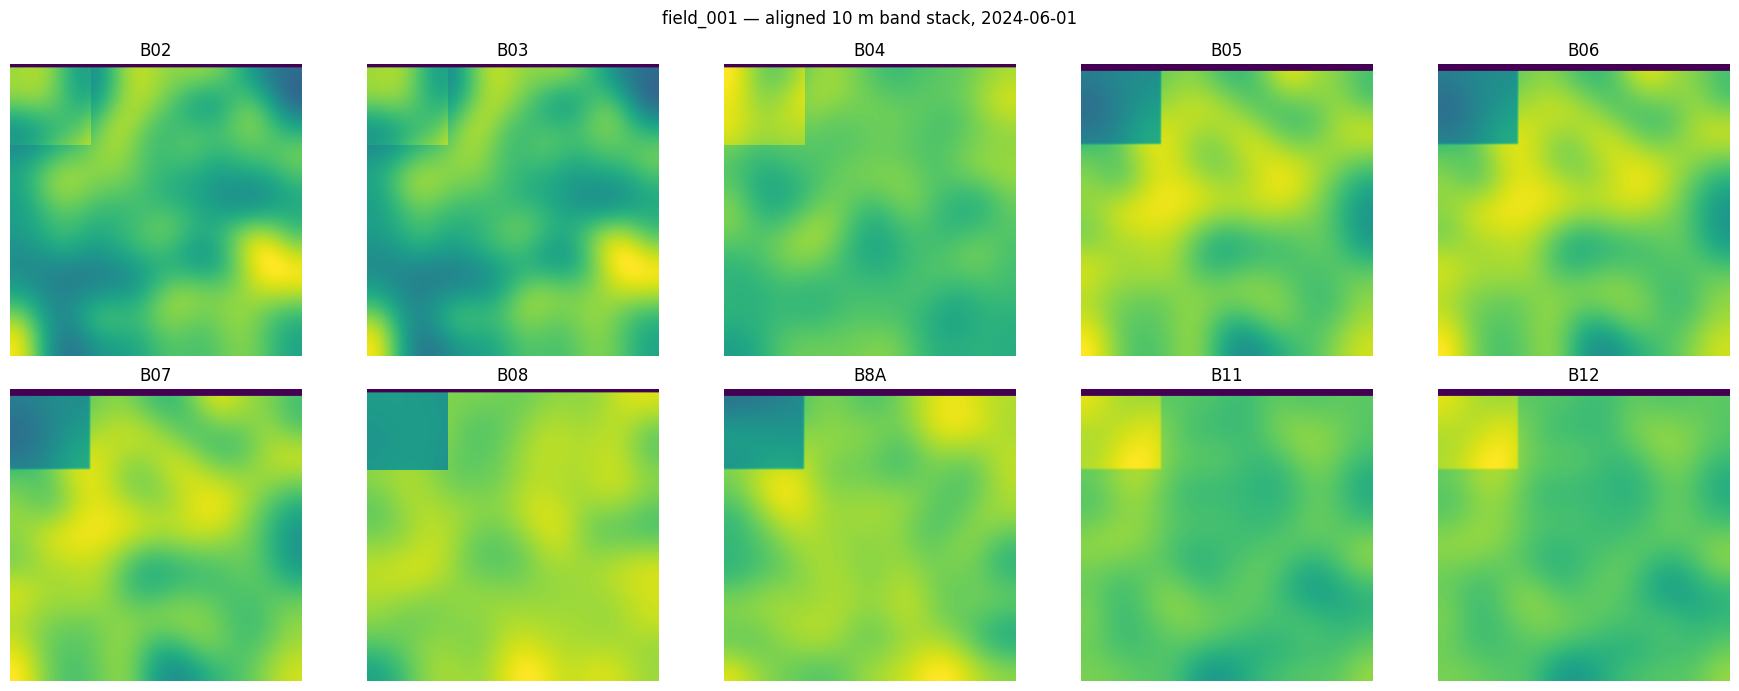

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, name, band in zip(axes.flat, SENTINEL2_BANDS, cube):
    im = ax.imshow(band, cmap="viridis")
    ax.set_title(name)
    ax.axis("off")
fig.suptitle(f"{FIELD_ID} — aligned 10 m band stack, {check_date}")
plt.tight_layout()
plt.show()


### Summary
- Every band now shares the same shape, transform, and CRS — ready for `extract_patches()` in `src/preprocessing.py`.
- Files are saved to `data/raw/sentinel2/<field_id>/<date>.tif`, one 10-band GeoTIFF per date, matching exactly what `02_preprocessing.ipynb` expects.
- If `USE_SYNTHETIC = True`, delete `data/raw/sentinel2_native/` and `data/raw/sentinel2/` and re-run with `USE_SYNTHETIC = False` (and working internet access) to replace this with real imagery.
- Next: add a matching `data/raw/sensors/<field_id>.csv` (soil moisture, temperature, humidity readings) and `data/labels/<field_id>.csv`, then continue with `01_data_exploration.ipynb`.